# Jaguar Dataset Analysis

This notebook provides comprehensive analysis of the master jaguar dataset:
- Load dataset from disk or FiftyOne
- Identity distribution histograms
- Embedding visualizations (t-SNE, UMAP)
- Duplicate analysis
- Segmentation statistics
- Data quality checks

## Setup and Imports

In [1]:
import sys
from pathlib import Path
import logging

# Add src to path if needed
project_root = Path.cwd().parent / "camera-trap-footage"
sys.path.insert(0, str(project_root / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import umap

import fiftyone as fo
from fiftyone import ViewField as F

from jaguars.common.logging_utils import setup_logger
from jaguars.common.config import JID_MASTER_DATASET

# Setup logging
logger = setup_logger("dataset_analysis", level=logging.INFO)

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("✓ Imports successful")

✓ Imports successful


## Configuration

In [6]:
# Dataset configuration
DATASET_NAME = JID_MASTER_DATASET  # "JID_Master_Dataset"
DATASET_DISK_PATH = project_root / "data" / "intermediate" / "v1" / "fo_jaguars" / "exports" / "master"

# Whether to load from disk or use existing FiftyOne dataset
LOAD_FROM_DISK = False
OVERWRITE_IF_EXISTS = False

# Field names
JAGUAR_ID_FIELD = "jaguar_id"
GROUND_TRUTH_FIELD = "ground_truth"
SEGMENTATION_FIELD = "sam3_segmentations"
EMBEDDING_FIELD = "embeddings_BVRA_MegaDescriptor_L_384"
EMBEDDING_PATCHES_FIELD = "embeddings_BVRA_MegaDescriptor_L_384"
DEDUP_FIELD = "is_duplicate"

# Analysis parameters
RANDOM_SEED = 42

print("Configuration:")
print(f"  Dataset name: {DATASET_NAME}")
print(f"  Load from disk: {LOAD_FROM_DISK}")
print(f"  Disk path: {DATASET_DISK_PATH}")
print(f"  Overwrite existing: {OVERWRITE_IF_EXISTS}")

Configuration:
  Dataset name: JID_Master_Dataset
  Load from disk: False
  Disk path: /sc/home/philipp.kolbe/JID/camera-trap-footage/camera-trap-footage/data/intermediate/v1/fo_jaguars/exports/master
  Overwrite existing: False


## Load Dataset

Load the dataset from disk or FiftyOne.

In [3]:
# Check if dataset exists
dataset_exists = fo.dataset_exists(DATASET_NAME)

if LOAD_FROM_DISK:
    print("=" * 70)
    print("Loading dataset from disk")
    print("=" * 70)
    
    # Delete existing if requested
    if dataset_exists and OVERWRITE_IF_EXISTS:
        print(f"Deleting existing dataset '{DATASET_NAME}'...")
        fo.delete_dataset(DATASET_NAME)
        dataset_exists = False
    
    if dataset_exists:
        print(f"⚠ Dataset '{DATASET_NAME}' already exists")
        print("Set OVERWRITE_IF_EXISTS=True to reload from disk")
        dataset = fo.load_dataset(DATASET_NAME)
    else:
        if not DATASET_DISK_PATH.exists():
            raise ValueError(f"Dataset not found at {DATASET_DISK_PATH}")
        
        print(f"Loading from: {DATASET_DISK_PATH}")
        dataset = fo.Dataset.from_dir(
            dataset_dir=str(DATASET_DISK_PATH),
            dataset_type=fo.types.FiftyOneDataset,
            name=DATASET_NAME,
        )
        print(f"✓ Dataset loaded and saved as '{DATASET_NAME}'")
else:
    print("=" * 70)
    print("Loading existing FiftyOne dataset")
    print("=" * 70)
    
    if not dataset_exists:
        raise ValueError(f"Dataset '{DATASET_NAME}' does not exist in FiftyOne")
    
    dataset = fo.load_dataset(DATASET_NAME)
    print(f"✓ Loaded dataset '{DATASET_NAME}'")

print(f"\nDataset info:")
print(f"  Total samples: {len(dataset)}")
print(f"  Group field: {dataset.group_field}")
if dataset.group_field:
    images_view = dataset.select_group_slices("image")
    videos_view = dataset.select_group_slices("video")
    print(f"  Image samples: {len(images_view)}")
    print(f"  Video samples: {len(videos_view)}")

Loading existing FiftyOne dataset
✓ Loaded dataset 'JID_Master_Dataset'

Dataset info:
  Total samples: 1171
  Group field: group
  Image samples: 1171
  Video samples: 230


## Dataset Overview

Basic statistics and field information.

In [5]:
images_view.first()

<SampleView: {
    'id': '6980821c341041adb61e5d4c',
    'media_type': 'image',
    'filepath': '/sc/home/philipp.kolbe/JID/camera-trap-footage/data/raw/17_11_2025/sites/SITE 4/PHOTOS ID/DSCF0357.JPG',
    'tags': ['train'],
    'metadata': None,
    'created_at': datetime.datetime(2026, 2, 2, 10, 53, 16, 637000),
    'last_modified_at': datetime.datetime(2026, 2, 2, 13, 18, 26, 792000),
    'group': <Group: {'id': '6980821c341041adb61e5b58', 'name': 'image'}>,
    'source_type': 'csv',
    'source': 'csv_17_11_2025',
    'csv_source': '/sc/home/philipp.kolbe/JID/camera-trap-footage/data/raw/17_11_2025/labels.csv',
    'jaguar_id': 'BAGUA',
    'ground_truth': <Classification: {
        'id': '6980821c341041adb61e5b59',
        'tags': [],
        'label': 'BAGUA',
        'confidence': None,
        'logits': None,
    }>,
    'site': 'SITE 4',
    'cam': 'B',
    'sighting_id': 'S2',
    'date': '2024-07-11',
    'time': '19:11:03',
    'datetime': '2024-07-11 19:11:03',
    'locatio

In [ ]:
# Get image view for analysis
images_view = dataset.select_group_slices("image") if dataset.group_field else dataset

print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)

# Field schema
print("\nField schema:")
for field_name, field_type in images_view.get_field_schema().items():
    print(f"  {field_name}: {field_type}")

# Tags
print(f"\nTags: {images_view.distinct('tags')}")

# Check for required fields
print("\nField availability:")
print(f"  {JAGUAR_ID_FIELD}: {'✓' if JAGUAR_ID_FIELD in images_view.get_field_schema() else '✗'}")
print(f"  {GROUND_TRUTH_FIELD}: {'✓' if GROUND_TRUTH_FIELD in images_view.get_field_schema() else '✗'}")
print(f"  {SEGMENTATION_FIELD}: {'✓' if SEGMENTATION_FIELD in images_view.get_field_schema() else '✗'}")
print(f"  {EMBEDDING_FIELD}: {'✓' if EMBEDDING_FIELD in images_view.get_field_schema() else '✗'}")
print(f"  {EMBEDDING_PATCHES_FIELD}: {'✓' if EMBEDDING_PATCHES_FIELD in images_view.get_field_schema() else '✗'}")
print(f"  {DEDUP_FIELD}: {'✓' if DEDUP_FIELD in images_view.get_field_schema() else '✗'}")

DATASET OVERVIEW

Field schema:
  id: fiftyone.core.fields.ObjectIdField
  filepath: fiftyone.core.fields.StringField
  tags: fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
  metadata: fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.Metadata)
  created_at: fiftyone.core.fields.DateTimeField
  last_modified_at: fiftyone.core.fields.DateTimeField
  group: fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.groups.Group)
  source_type: fiftyone.core.fields.StringField
  source: fiftyone.core.fields.StringField
  csv_source: fiftyone.core.fields.StringField
  jaguar_id: fiftyone.core.fields.StringField
  ground_truth: fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Classification)
  site: fiftyone.core.fields.StringField
  cam: fiftyone.core.fields.StringField
  sighting_id: fiftyone.core.fields.StringField
  date: fiftyone.core.fields.StringField
  time: fiftyone.core.fields.StringField
  datetime: fiftyone.core.fields.StringField
 

## Identity Distribution

Analyze the distribution of jaguar identities.

IDENTITY DISTRIBUTION

Total unique jaguars: 76
Identities: ['BAGUA', 'BORORO', 'BUHEE', 'CARO', 'CF1', 'CF2', 'CLEO', 'ESTELA', 'F1', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F17', 'F18', 'F19', 'F2', 'F20', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9', 'FORASTEIRO', 'IPEPO', 'M1', 'M10', 'M11', 'M12', 'M13', 'M14', 'M14/M15', 'M16', 'M17', 'M18', 'M19', 'M2/FORASTEIRO', 'M20', 'M3', 'M4', 'M6', 'M7', 'M8', 'M9', 'MARGO', 'NECIO', 'NF1', 'NF2', 'NF3', 'NF4', 'OUSADO', 'OVERA', 'RAJ', 'SIRIRI', 'SRIRI', 'TOMAS', 'U1', 'U11', 'U12', 'U12 COULD BE F15', 'U13', 'U14', 'U15', 'U16', 'U18', 'U2', 'U3', 'U32', 'U5', 'U6', 'U8']


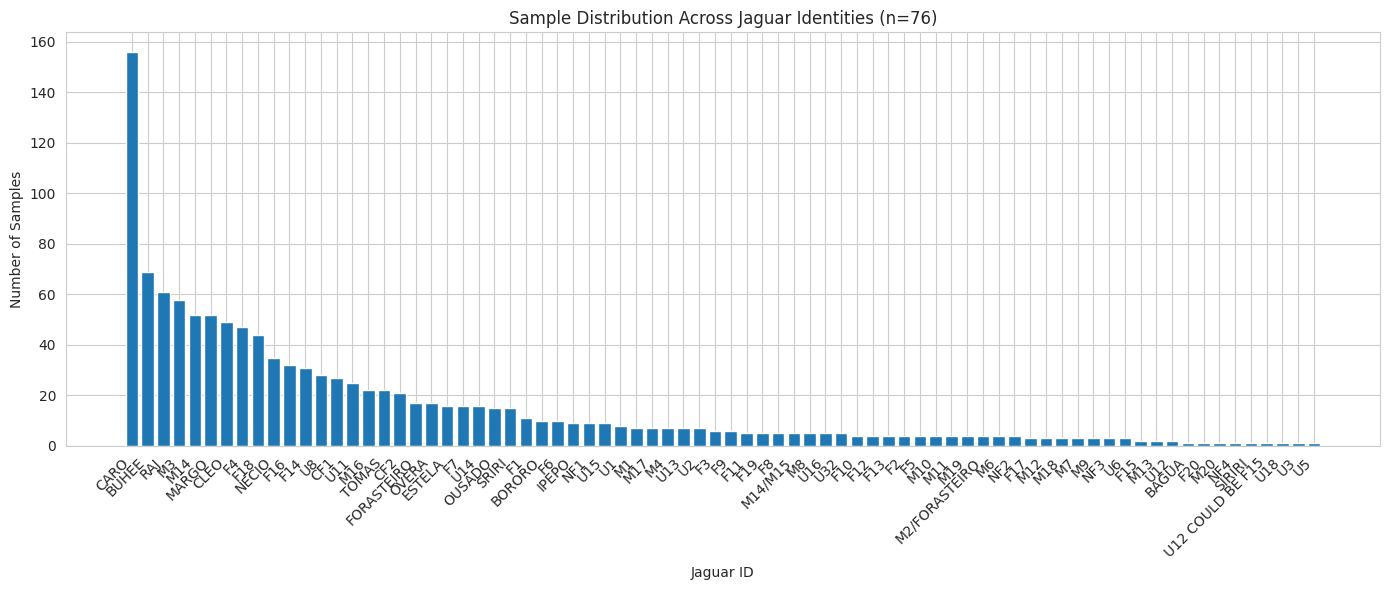


Sample count statistics:
  Mean: 15.4
  Median: 6.0
  Min: 1
  Max: 156
  Std: 22.9

Top 10 identities by sample count:
  1. CARO: 156 samples
  2. BUHEE: 69 samples
  3. RAJ: 61 samples
  4. M3: 58 samples
  5. M14: 52 samples
  6. MARGO: 52 samples
  7. CLEO: 49 samples
  8. F4: 47 samples
  9. F18: 44 samples
  10. NECIO: 35 samples

Bottom 10 identities by sample count:
  1. U12: 2 samples
  2. BAGUA: 1 samples
  3. F20: 1 samples
  4. M20: 1 samples
  5. NF4: 1 samples
  6. SIRIRI: 1 samples
  7. U12 COULD BE F15: 1 samples
  8. U18: 1 samples
  9. U3: 1 samples
  10. U5: 1 samples


In [8]:
print("=" * 70)
print("IDENTITY DISTRIBUTION")
print("=" * 70)

# Get identity field (try both jaguar_id and ground_truth)
identity_field = None
if JAGUAR_ID_FIELD in images_view.get_field_schema():
    identity_field = JAGUAR_ID_FIELD
elif GROUND_TRUTH_FIELD in images_view.get_field_schema():
    identity_field = GROUND_TRUTH_FIELD

if identity_field:
    # Get unique identities
    identities = images_view.distinct(identity_field)
    identities = [i for i in identities if i is not None]
    
    print(f"\nTotal unique jaguars: {len(identities)}")
    print(f"Identities: {sorted(identities)}")
    
    # Count samples per identity
    identity_counts = {}
    for identity in identities:
        count = len(images_view.match(F(identity_field) == identity))
        identity_counts[identity] = count
    
    # Create histogram
    plt.figure(figsize=(14, 6))
    
    # Sort by count for better visualization
    sorted_items = sorted(identity_counts.items(), key=lambda x: x[1], reverse=True)
    ids, counts = zip(*sorted_items)
    
    plt.bar(range(len(ids)), counts)
    plt.xlabel('Jaguar ID')
    plt.ylabel('Number of Samples')
    plt.title(f'Sample Distribution Across Jaguar Identities (n={len(identities)})')
    plt.xticks(range(len(ids)), ids, rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    # Statistics
    counts_array = np.array(list(identity_counts.values()))
    print(f"\nSample count statistics:")
    print(f"  Mean: {counts_array.mean():.1f}")
    print(f"  Median: {np.median(counts_array):.1f}")
    print(f"  Min: {counts_array.min()}")
    print(f"  Max: {counts_array.max()}")
    print(f"  Std: {counts_array.std():.1f}")
    
    # Show top 10 and bottom 10
    print(f"\nTop 10 identities by sample count:")
    for i, (identity, count) in enumerate(sorted_items[:10], 1):
        print(f"  {i}. {identity}: {count} samples")
    
    if len(sorted_items) > 10:
        print(f"\nBottom 10 identities by sample count:")
        for i, (identity, count) in enumerate(sorted_items[-10:], 1):
            print(f"  {i}. {identity}: {count} samples")
else:
    print("⚠ No identity field found")

In [ ]:
print("=" * 70)
print("PER TAG IDENTITY DISTRIBUTION")
print("=" * 70)

# Check if tags exist
if "tags" in images_view.get_field_schema():
    tags = images_view.distinct("tags")
    print(f"\nTags: {tags}")
    
    # Initialize dictionary to store counts per tag
    tag_identity_counts = {}
    
    for tag in tags:
        # Filter dataset by tag
        tagged_view = images_view.match(F("tags").contains(tag))
        
        # Get unique identities in this tag group
        identities = tagged_view.distinct(identity_field) if identity_field else []
        identities = [i for i in identities if i is not None]
        
        tag_identity_counts[tag] = len(identities)
        print(f"Tag: {tag}, Unique Identities: {len(identities)}")
    
    # Display summary
    print("\nSummary of Unique Identities per Tag:")
    for tag, count in tag_identity_counts.items():
        print(f"  {tag}: {count} unique identities")
else:
    print("⚠ No tags field found in the dataset")

## Duplicate Analysis

Analyze near-duplicate images.

DUPLICATE ANALYSIS

Duplicate statistics:
  Total samples: 1171
  Duplicates: 106 (9.1%)
  Unique samples: 1065 (90.9%)


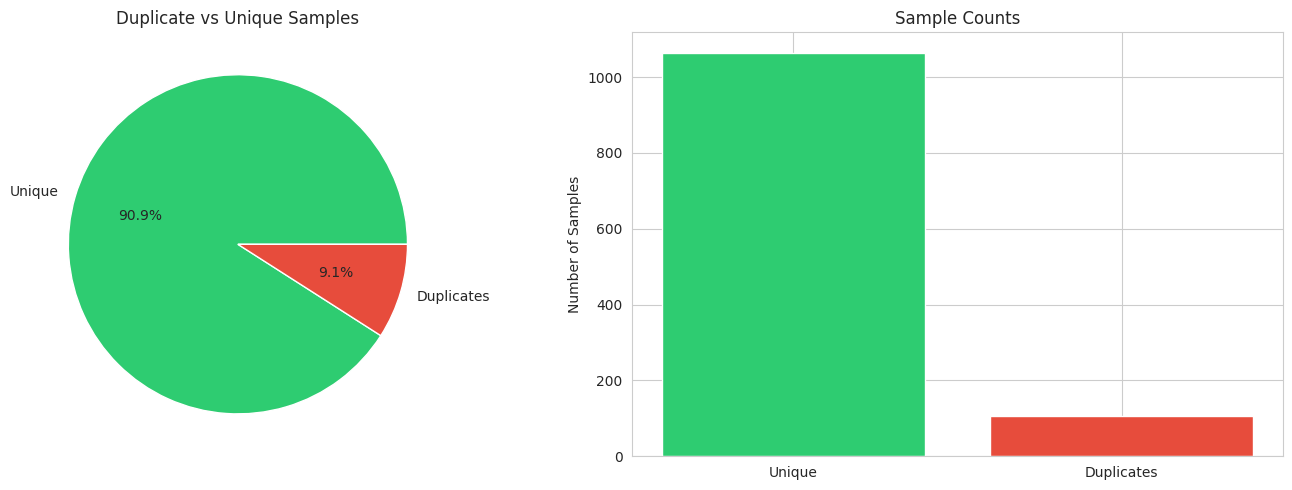

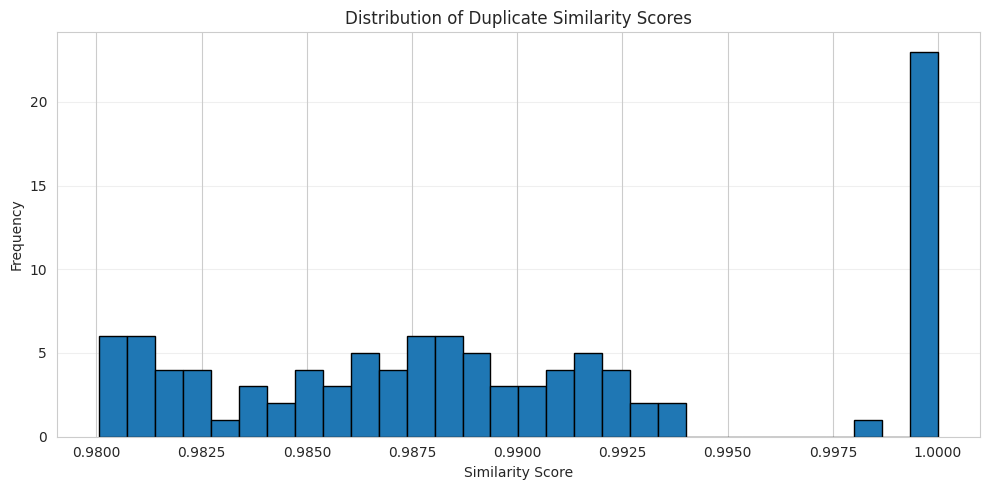


Similarity score statistics:
  Mean: 0.990
  Median: 0.989
  Min: 0.980
  Max: 1.000


In [9]:
print("=" * 70)
print("DUPLICATE ANALYSIS")
print("=" * 70)

if DEDUP_FIELD in images_view.get_field_schema():
    # Count duplicates
    duplicates_view = images_view.match(F(DEDUP_FIELD) == True)
    non_duplicates_view = images_view.match(F(DEDUP_FIELD) != True)
    
    n_duplicates = len(duplicates_view)
    n_total = len(images_view)
    
    print(f"\nDuplicate statistics:")
    print(f"  Total samples: {n_total}")
    print(f"  Duplicates: {n_duplicates} ({100 * n_duplicates / n_total:.1f}%)")
    print(f"  Unique samples: {len(non_duplicates_view)} ({100 * len(non_duplicates_view) / n_total:.1f}%)")
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Pie chart
    ax1.pie([len(non_duplicates_view), n_duplicates], 
            labels=['Unique', 'Duplicates'],
            autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'])
    ax1.set_title('Duplicate vs Unique Samples')
    
    # Bar chart
    ax2.bar(['Unique', 'Duplicates'], [len(non_duplicates_view), n_duplicates],
            color=['#2ecc71', '#e74c3c'])
    ax2.set_ylabel('Number of Samples')
    ax2.set_title('Sample Counts')
    
    plt.tight_layout()
    plt.show()
    
    # Check if duplicate_similarity field exists
    if "duplicate_similarity" in images_view.get_field_schema():
        # Get similarity scores for duplicates
        similarities = []
        for sample in duplicates_view:
            if sample.duplicate_similarity is not None:
                similarities.append(sample.duplicate_similarity)
        
        if similarities:
            plt.figure(figsize=(10, 5))
            plt.hist(similarities, bins=30, edgecolor='black')
            plt.xlabel('Similarity Score')
            plt.ylabel('Frequency')
            plt.title('Distribution of Duplicate Similarity Scores')
            plt.grid(axis='y', alpha=0.3)
            plt.tight_layout()
            plt.show()
            
            print(f"\nSimilarity score statistics:")
            print(f"  Mean: {np.mean(similarities):.3f}")
            print(f"  Median: {np.median(similarities):.3f}")
            print(f"  Min: {np.min(similarities):.3f}")
            print(f"  Max: {np.max(similarities):.3f}")
else:
    print("⚠ No duplicate field found")

## Segmentation Statistics

Analyze segmentation results.

SEGMENTATION STATISTICS

Segmentation coverage:
  With segmentation: 1171 (100.0%)
  Without segmentation: 0 (0.0%)


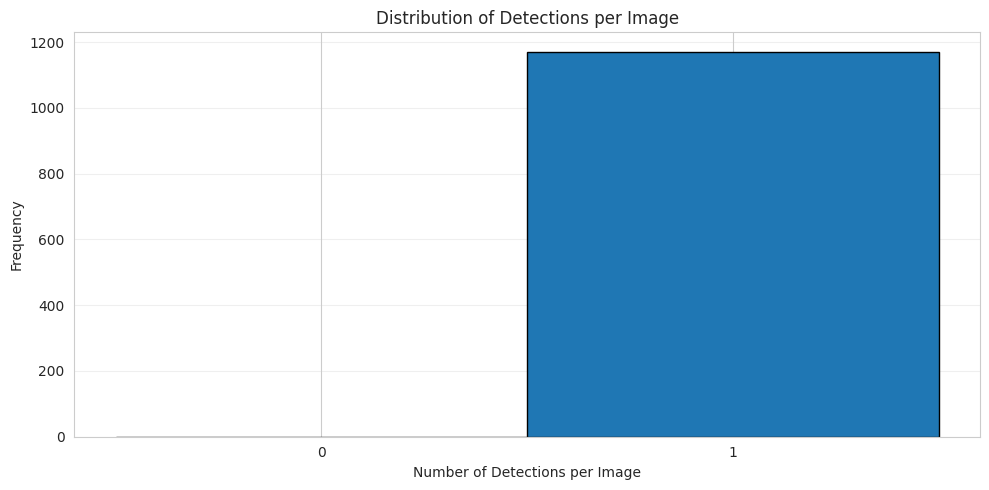


Detection count statistics:
  Mean: 1.00
  Median: 1.0
  Min: 1
  Max: 1

Samples with exactly 1 detection: 1171 (100.0%)


In [10]:
print("=" * 70)
print("SEGMENTATION STATISTICS")
print("=" * 70)

if SEGMENTATION_FIELD in images_view.get_field_schema():
    # Count samples with/without segmentation
    with_seg = images_view.exists(SEGMENTATION_FIELD)
    without_seg = images_view.match((F(SEGMENTATION_FIELD) == None) | (~F(SEGMENTATION_FIELD).exists()))
    
    print(f"\nSegmentation coverage:")
    print(f"  With segmentation: {len(with_seg)} ({100 * len(with_seg) / len(images_view):.1f}%)")
    print(f"  Without segmentation: {len(without_seg)} ({100 * len(without_seg) / len(images_view):.1f}%)")
    
    # Detection counts
    if len(with_seg) > 0:
        detection_counts = []
        for sample in with_seg:
            if sample[SEGMENTATION_FIELD] is not None:
                detection_counts.append(len(sample[SEGMENTATION_FIELD].detections))
        
        if detection_counts:
            plt.figure(figsize=(10, 5))
            plt.hist(detection_counts, bins=range(max(detection_counts) + 2), edgecolor='black', align='left')
            plt.xlabel('Number of Detections per Image')
            plt.ylabel('Frequency')
            plt.title('Distribution of Detections per Image')
            plt.xticks(range(max(detection_counts) + 1))
            plt.grid(axis='y', alpha=0.3)
            plt.tight_layout()
            plt.show()
            
            print(f"\nDetection count statistics:")
            print(f"  Mean: {np.mean(detection_counts):.2f}")
            print(f"  Median: {np.median(detection_counts):.1f}")
            print(f"  Min: {np.min(detection_counts)}")
            print(f"  Max: {np.max(detection_counts)}")
            
            # Count samples with exactly 1 detection
            single_detection = sum(1 for c in detection_counts if c == 1)
            print(f"\nSamples with exactly 1 detection: {single_detection} ({100 * single_detection / len(detection_counts):.1f}%)")
else:
    print("⚠ No segmentation field found")

## Embedding Visualization

Visualize embeddings using t-SNE and UMAP.

EMBEDDING VISUALIZATION
Using full image embeddings: embeddings_BVRA_MegaDescriptor_L_384

Embeddings shape: (1171, 1536)
Number of samples: 1171
Embedding dimension: 1536

Computing t-SNE projection...


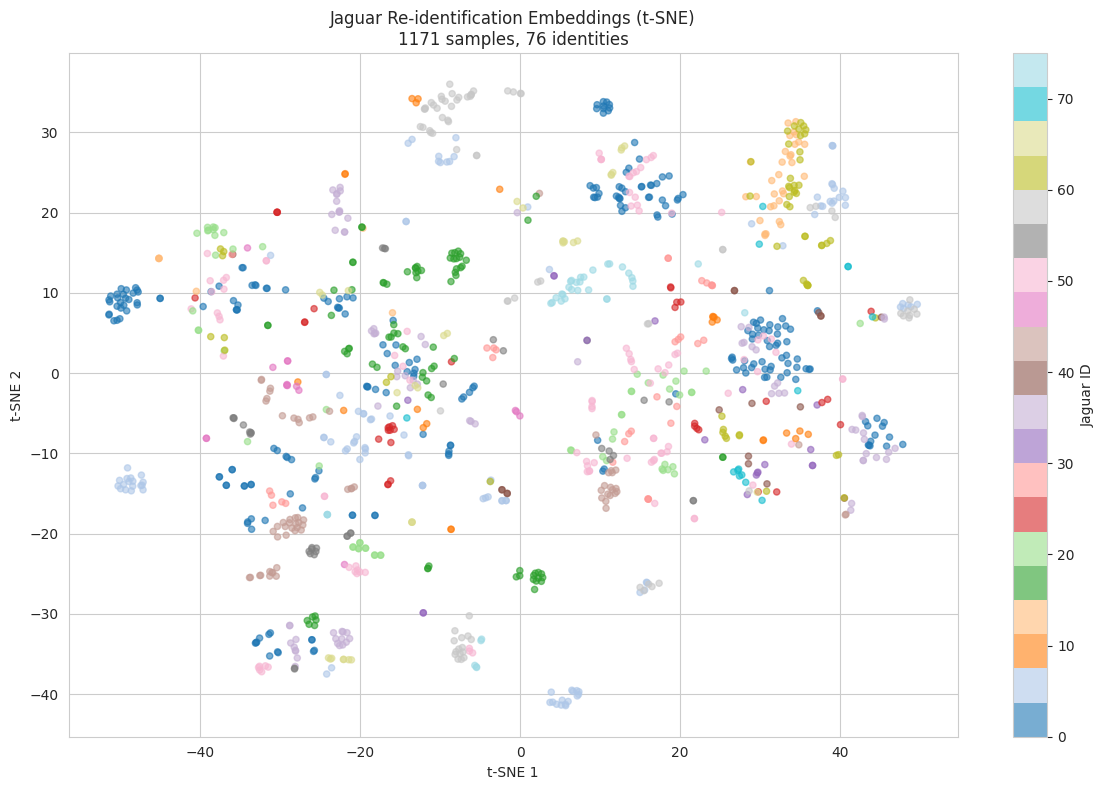

Computing UMAP projection...


/sc/home/philipp.kolbe/conda3/envs/jid/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


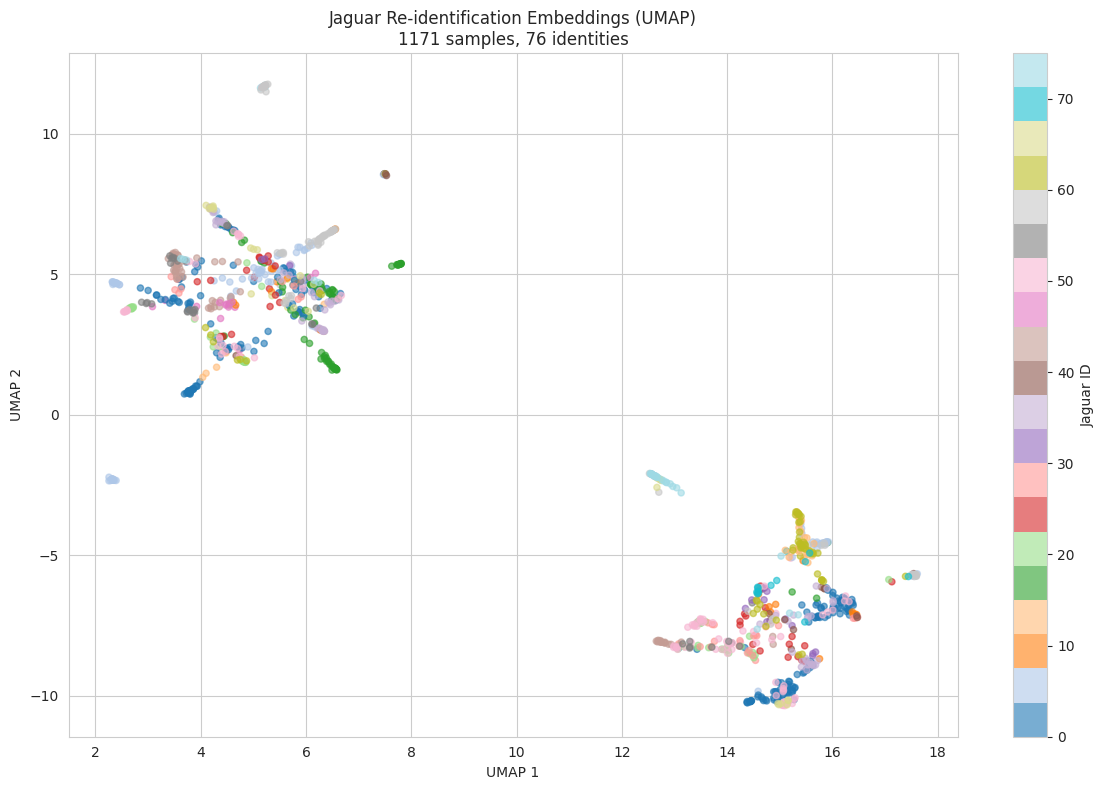

In [11]:
print("=" * 70)
print("EMBEDDING VISUALIZATION")
print("=" * 70)

# Determine which embedding field to use
embedding_field_to_use = None
if EMBEDDING_FIELD in images_view.get_field_schema():
    embedding_field_to_use = EMBEDDING_FIELD
    print(f"Using full image embeddings: {EMBEDDING_FIELD}")
elif EMBEDDING_PATCHES_FIELD in images_view.get_field_schema():
    # Check if it's at sample level or detection level
    sample = images_view.first()
    if hasattr(sample, EMBEDDING_PATCHES_FIELD) and sample[EMBEDDING_PATCHES_FIELD] is not None:
        embedding_field_to_use = EMBEDDING_PATCHES_FIELD
        print(f"Using patch embeddings: {EMBEDDING_PATCHES_FIELD}")

if embedding_field_to_use:
    # Extract embeddings and labels
    embeddings_list = []
    labels_list = []
    sample_ids = []
    
    for sample in images_view:
        if sample[embedding_field_to_use] is not None:
            embeddings_list.append(sample[embedding_field_to_use])
            
            # Get identity
            identity = None
            if identity_field and sample[identity_field] is not None:
                identity = sample[identity_field]
            labels_list.append(identity)
            sample_ids.append(sample.id)
    
    if len(embeddings_list) > 0:
        embeddings = np.array(embeddings_list)
        labels = np.array(labels_list)
        
        print(f"\nEmbeddings shape: {embeddings.shape}")
        print(f"Number of samples: {len(embeddings)}")
        print(f"Embedding dimension: {embeddings.shape[1]}")
        
        # Limit to subset for faster visualization
        max_samples = 2000
        if len(embeddings) > max_samples:
            print(f"\nSubsampling {max_samples} samples for visualization...")
            indices = np.random.choice(len(embeddings), max_samples, replace=False)
            embeddings_sub = embeddings[indices]
            labels_sub = labels[indices]
        else:
            embeddings_sub = embeddings
            labels_sub = labels
        
        # Create numeric labels for coloring
        unique_labels = sorted([l for l in set(labels_sub) if l is not None])
        label_to_id = {label: i for i, label in enumerate(unique_labels)}
        label_ids = np.array([label_to_id.get(l, -1) for l in labels_sub])
        
        # t-SNE
        print("\nComputing t-SNE projection...")
        tsne = TSNE(n_components=2, random_state=RANDOM_SEED, perplexity=30)
        embeddings_tsne = tsne.fit_transform(embeddings_sub)
        
        plt.figure(figsize=(12, 8))
        scatter = plt.scatter(
            embeddings_tsne[:, 0],
            embeddings_tsne[:, 1],
            c=label_ids,
            cmap='tab20',
            alpha=0.6,
            s=20
        )
        plt.colorbar(scatter, label='Jaguar ID')
        plt.title(f'Jaguar Re-identification Embeddings (t-SNE)\n{len(embeddings_sub)} samples, {len(unique_labels)} identities')
        plt.xlabel('t-SNE 1')
        plt.ylabel('t-SNE 2')
        plt.tight_layout()
        plt.show()
        
        # UMAP
        print("Computing UMAP projection...")
        reducer = umap.UMAP(n_components=2, random_state=RANDOM_SEED, n_neighbors=15)
        embeddings_umap = reducer.fit_transform(embeddings_sub)
        
        plt.figure(figsize=(12, 8))
        scatter = plt.scatter(
            embeddings_umap[:, 0],
            embeddings_umap[:, 1],
            c=label_ids,
            cmap='tab20',
            alpha=0.6,
            s=20
        )
        plt.colorbar(scatter, label='Jaguar ID')
        plt.title(f'Jaguar Re-identification Embeddings (UMAP)\n{len(embeddings_sub)} samples, {len(unique_labels)} identities')
        plt.xlabel('UMAP 1')
        plt.ylabel('UMAP 2')
        plt.tight_layout()
        plt.show()
    else:
        print("⚠ No embeddings found")
else:
    print("⚠ No embedding field found")

## Data Quality Checks

Check for potential data quality issues.

In [12]:
print("=" * 70)
print("DATA QUALITY CHECKS")
print("=" * 70)

# Missing identity labels
if identity_field:
    missing_identity = images_view.match(F(identity_field) == None)
    print(f"\nMissing identity labels: {len(missing_identity)} samples")
    if len(missing_identity) > 0:
        print(f"  ({100 * len(missing_identity) / len(images_view):.1f}% of total)")

# Samples with multiple detections (if expecting 1)
if SEGMENTATION_FIELD in images_view.get_field_schema():
    multiple_detections = images_view.match(F(f"{SEGMENTATION_FIELD}.detections").length() > 1)
    print(f"\nSamples with >1 detection: {len(multiple_detections)}")
    if len(multiple_detections) > 0:
        print(f"  ({100 * len(multiple_detections) / len(images_view):.1f}% of samples with segmentation)")

# Check for samples without embeddings
if embedding_field_to_use:
    no_embeddings = images_view.match(F(embedding_field_to_use) == None)
    print(f"\nSamples without embeddings: {len(no_embeddings)}")
    if len(no_embeddings) > 0:
        print(f"  ({100 * len(no_embeddings) / len(images_view):.1f}% of total)")

# Source type distribution (if exists)
if "source_type" in images_view.get_field_schema():
    source_types = images_view.distinct("source_type")
    print(f"\nSource type distribution:")
    for source_type in source_types:
        count = len(images_view.match(F("source_type") == source_type))
        print(f"  {source_type}: {count} samples ({100 * count / len(images_view):.1f}%)")

print("\n" + "=" * 70)
print("Analysis complete!")
print("=" * 70)

DATA QUALITY CHECKS

Missing identity labels: 0 samples

Samples with >1 detection: 0

Samples without embeddings: 0

Source type distribution:
  csv: 19 samples (1.6%)
  pptx: 122 samples (10.4%)
  video_frame: 1030 samples (88.0%)

Analysis complete!


## Dataset Curation Summary for Report (HF FiftyOne Export)

This section analyzes the published Hugging Face dataset directly from its FiftyOne export artifacts (`metadata.json`, `samples.json`) and links the statistics to the ingestion workflow in `ingestion_pipeline.ipynb`.

**Implemented curation workflow (code-aligned):**
1. CSV + PPTX ingestion into grouped FiftyOne dataset
2. Video frame sampling (early dense + later sparse policy)
3. SAM3 segmentation (`prompt='jaguar'`)
4. Tag-only filtering for segmentation count/quality (`filter_count`, `filter_quality`)
5. Embedding computation
6. Closed-set split assignment (`closed_set_split`)
7. Deduplication flagging (`is_duplicate`, `duplicate` tag)
8. Export/publish derived variants

In [ ]:
from collections import Counter
from huggingface_hub import hf_hub_download
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

HF_REPO = "JaguarCameraTrap/jaguars_camera_trap_0226-segmented_deduplicated"
metadata_path = hf_hub_download(repo_id=HF_REPO, repo_type="dataset", filename="metadata.json")
samples_path = hf_hub_download(repo_id=HF_REPO, repo_type="dataset", filename="samples.json")

with open(metadata_path) as f:
    hf_metadata = json.load(f)
with open(samples_path) as f:
    hf_samples_payload = json.load(f)

hf_samples = hf_samples_payload.get("samples", [])
if not hf_samples:
    raise ValueError("No samples found in samples.json")

def _extract_label(sample):
    gt = sample.get("ground_truth")
    if isinstance(gt, dict):
        lbl = gt.get("label")
        if lbl is not None:
            return str(lbl)
    if sample.get("label") is not None:
        return str(sample.get("label"))
    if sample.get("jaguar_id") is not None:
        return str(sample.get("jaguar_id"))
    return None

rows = []
for s in hf_samples:
    rows.append(
        {
            "filepath": s.get("filepath"),
            "label": _extract_label(s),
            "split": s.get("closed_set_split") or s.get("split"),
            "closed_set_split": s.get("closed_set_split"),
            "source_type": s.get("source_type"),
            "site": s.get("site"),
            "is_duplicate": bool(s.get("is_duplicate", False)),
            "has_segmentation": s.get("sam3_segmentations") is not None,
            "tags": s.get("tags", []),
        }
    )

hf_df = pd.DataFrame(rows)
hf_df["label"] = hf_df["label"].fillna("__MISSING__")

print(f"HF repo: {HF_REPO}")
print(f"Total samples: {len(hf_df)}")
print(f"Unique identities (non-missing): {hf_df.loc[hf_df['label'] != '__MISSING__', 'label'].nunique()}")
print(f"Missing labels: {(hf_df['label'] == '__MISSING__').sum()}")
print(f"Split counts: {hf_df['split'].value_counts(dropna=False).to_dict()}")
print(f"Source counts: {hf_df['source_type'].value_counts(dropna=False).to_dict()}")
print(f"Duplicate-flagged samples: {int(hf_df['is_duplicate'].sum())}")
print(f"Samples with segmentation field: {int(hf_df['has_segmentation'].sum())}")

split_ct = hf_df['split'].value_counts(dropna=False)
plt.figure(figsize=(7, 4))
split_ct.plot(kind='bar')
plt.title('Closed-set split distribution (HF export)')
plt.xlabel('Split')
plt.ylabel('Samples')
plt.tight_layout()
plt.show()

In [ ]:
# Closed-set sanity check: val/test identities should be subset of train identities
train_ids = set(hf_df.loc[hf_df['split'] == 'train', 'label']) - {'__MISSING__'}
val_ids = set(hf_df.loc[hf_df['split'] == 'val', 'label']) - {'__MISSING__'}
test_ids = set(hf_df.loc[hf_df['split'] == 'test', 'label']) - {'__MISSING__'}

print(f"IDs in train: {len(train_ids)}")
print(f"IDs in val: {len(val_ids)}")
print(f"IDs in test: {len(test_ids)}")
print(f"Val IDs not in train: {len(val_ids - train_ids)}")
print(f"Test IDs not in train: {len(test_ids - train_ids)}")

# Identity frequency summary (long-tail statistics)
id_counts = hf_df.loc[hf_df['label'] != '__MISSING__', 'label'].value_counts()
print("Identity frequency summary:")
print(f"  min={int(id_counts.min())}, median={float(id_counts.median()):.1f}, mean={float(id_counts.mean()):.2f}, max={int(id_counts.max())}")

plt.figure(figsize=(8, 4))
plt.hist(id_counts.values, bins=30)
plt.title('Identity frequency distribution (all splits)')
plt.xlabel('Samples per identity')
plt.ylabel('Number of identities')
plt.tight_layout()
plt.show()

# Save report-ready table
report_dir = project_root / "notebooks" / "data" / "results" / "figures" / "report" / "dataset"
report_dir.mkdir(parents=True, exist_ok=True)

stats_table = pd.DataFrame(
    [
        {"metric": "n_samples_total", "value": int(len(hf_df))},
        {
            "metric": "n_unique_ids",
            "value": int(hf_df.loc[hf_df['label'] != '__MISSING__', 'label'].nunique()),
        },
        {"metric": "n_train", "value": int((hf_df['split'] == 'train').sum())},
        {"metric": "n_val", "value": int((hf_df['split'] == 'val').sum())},
        {"metric": "n_test", "value": int((hf_df['split'] == 'test').sum())},
        {"metric": "n_val_ids_not_in_train", "value": int(len(val_ids - train_ids))},
        {"metric": "n_test_ids_not_in_train", "value": int(len(test_ids - train_ids))},
        {"metric": "n_duplicate_flagged", "value": int(hf_df['is_duplicate'].sum())},
    ]
)
stats_table.to_csv(report_dir / "dataset_curation_stats.csv", index=False)
print(f"Saved: {report_dir / 'dataset_curation_stats.csv'}")

## Interactive Exploration

Launch FiftyOne App for interactive exploration.

In [18]:
# Launch FiftyOne App
session = fo.launch_app(dataset)
session

Dataset:         JID_Master_Dataset
Media type:      group
Num groups:      1171
Selected groups: 0
Selected labels: 0
Session URL:     http://localhost:5151/